# South German Credit Case Study
This case study aims to evaluate the performance of various machine learning models on the South German Credit dataset to determine which model provides the most reliable predictions for credit default.

Dataset:
South German Credit [Dataset]. (2019). UCI Machine Learning Repository. https://doi.org/10.24432/C5X89F.
***

## Notebook Objectives:
The goal for this notebook is to demonstrate the basic machine learning workflow from data exploration to model evaluation. This also shows my thought process when doing Python-driven data analysis.
***

## Required Libraries:
- Numpy
- Pandas
- Matplotlib
- Seaborn
- ScikitLearn
- Imblearn
- Tensorflow
- XGBoost
***

## Data Exploration

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [35]:
# Load data into dataframe
df = pd.read_csv(r"C:\Code\ML\south_german_credit\SouthGermanCredit.asc", sep = r'\s+')
df.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [34]:
# Translate column names
translations = {
    'laufkont': 'status',
    'laufzeit': 'duration',
    'moral': 'credit_history',
    'verw': 'purpose',
    'hoehe': 'amount',
    'sparkont': 'savings',
    'beszeit': 'employment_duration',
    'rate': 'installment_rate',
    'famges': 'personal_status_sex',
    'buerge': 'other_debtors',
    'wohnzeit': 'present_residence',
    'verm': 'property',
    'alter': 'age',
    'weitkred': 'other_installment_plans',
    'wohn': 'housing',
    'bishkred': 'number_credits',
    'beruf': 'job',
    'pers': 'people_liable',
    'telef': 'telephone',
    'gastarb': 'foreign_worker',
    'kredit': 'credit_risk'
}

df = df.rename(columns=translations)
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


### Data Profiling
After loading the data, it's important to have an overview of it to see what kind of data are we dealing with and if there's any cleaning that needs to be done.
- df.info(): This function is the fastest way to check if all data in a column has the same object type by looking at `Dtype`.
- df.isnull().sum(): This tells us how many null values do we have in our dataset.
- df.describe(): Shows the descriptive statistics for each numerical column. This is an easy way to spot if there are outliers.

Looking at the data below, there's a total of 1000 rows. We can see that all values are `int64` and we have no null values. Among the columns, `duration`, `amount`, and `age` are the only quantitative variables with no extreme outliers that require removal.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   int64
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   int64
 3   purpose                  1000 non-null   int64
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   int64
 6   employment_duration      1000 non-null   int64
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   int64
 9   other_debtors            1000 non-null   int64
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   int64
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   int64
 14  housing                  1000 non-null   int64
 15  number_credits  

In [6]:
missing_counts = df.isnull().sum()
print(f"Missing values per column:\n{missing_counts}")

Missing values per column:
status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64


In [7]:
df.describe()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,...,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,1.145000,...,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.845000,1.404000,1.963000,0.700000
std,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,0.477706,...,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856,0.458487
min,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,1.000000,...,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,1.000000,...,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,0.000000
50%,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,1.000000,...,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,1.000000
75%,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,1.000000,...,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000
max,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,3.000000,...,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000,1.000000


### Data Visualization
Visualizing data can help identify underlying trends and enable us make better initial assessment of our dataset. One example below is the feature `status` where we see that those who have favorable credit tend to be on the right side of the distribution, while higher-risk applicants on the other hand are primarily clustered to the left. This can be a strong predictor later on. We also see that some of the quantitative variables have high skewness which can be a problem later when training our model. The columns `duration`, `variable`, and `age` are heavily skewed to the right.

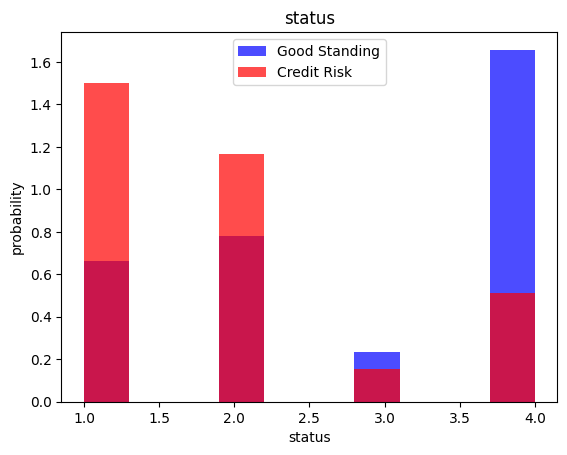

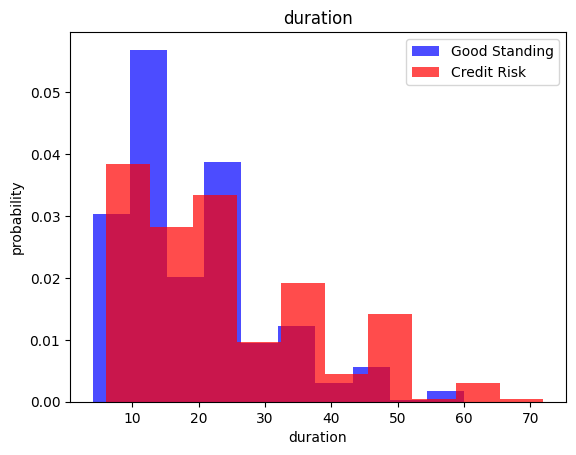

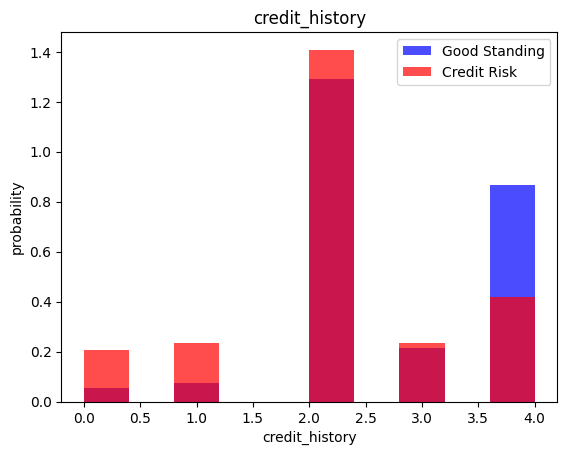

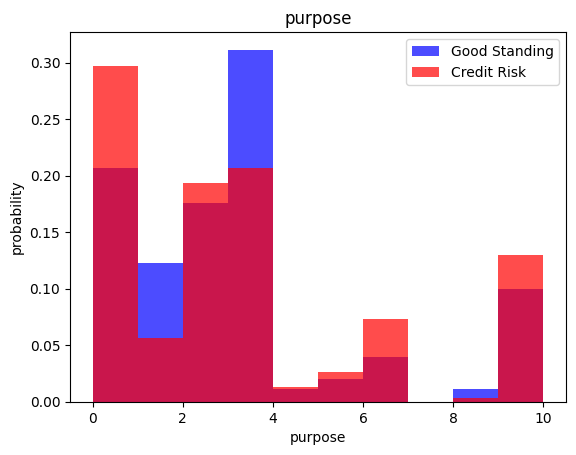

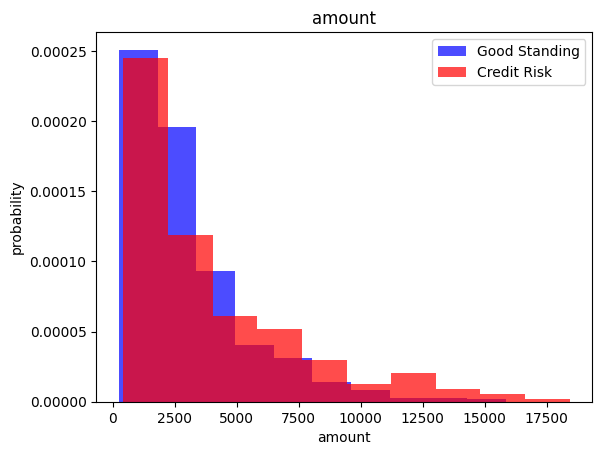

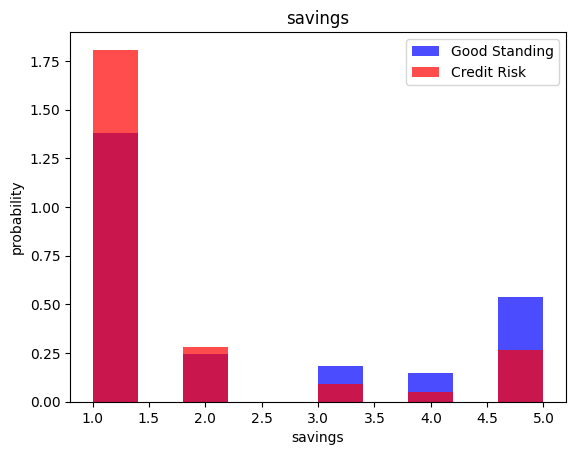

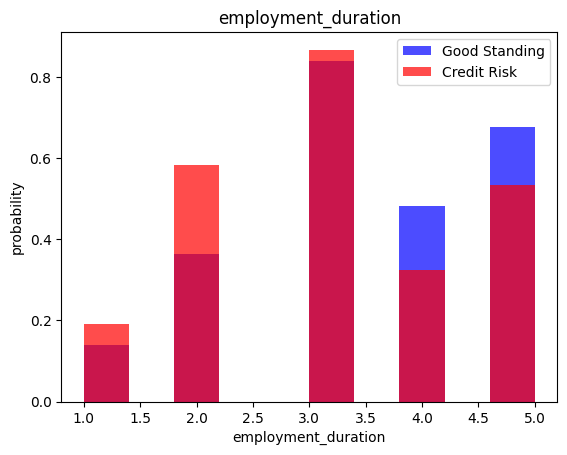

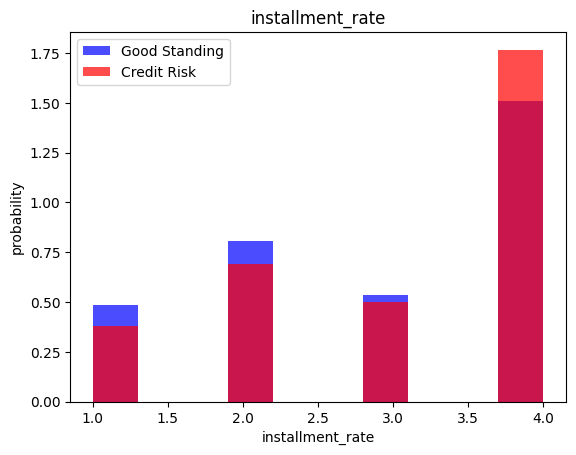

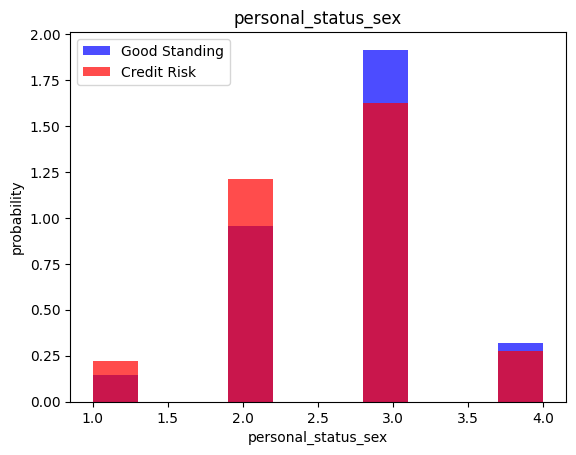

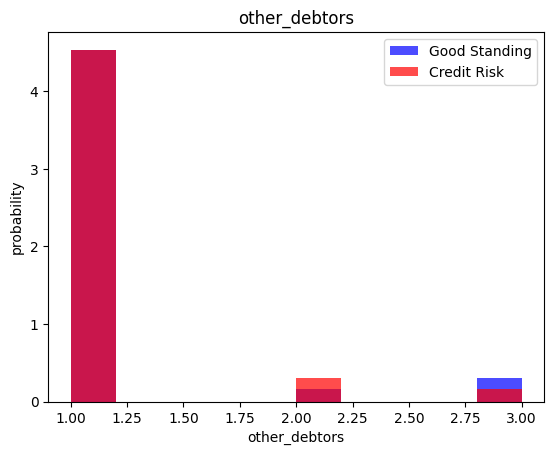

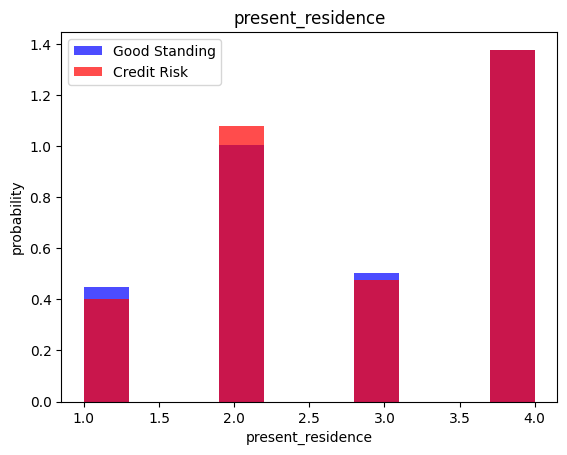

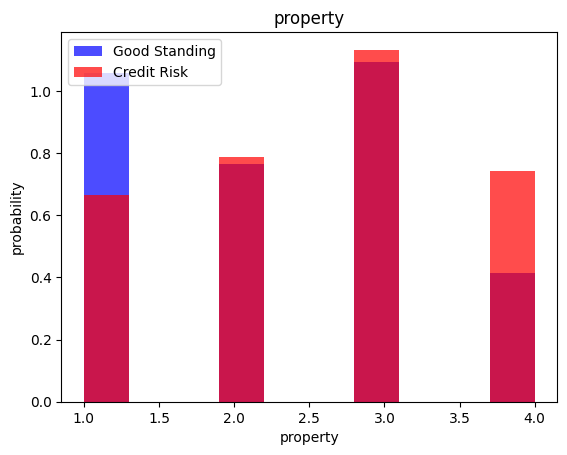

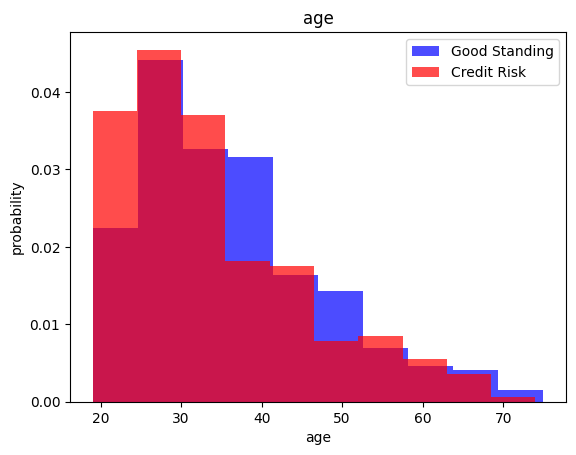

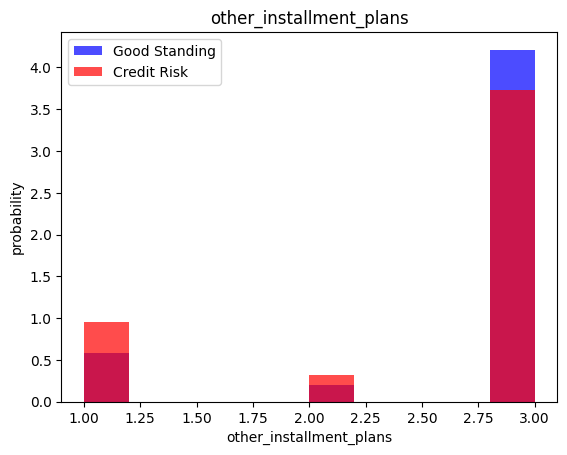

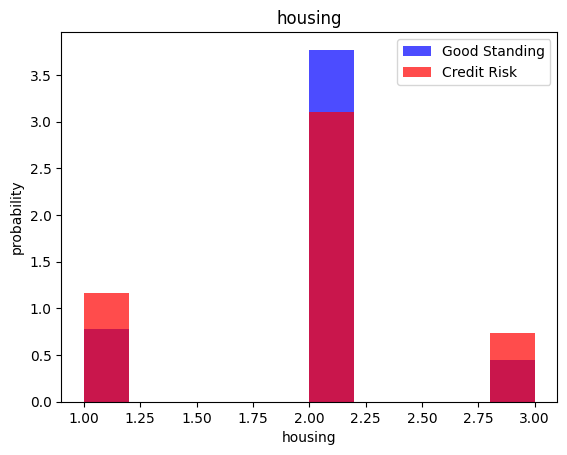

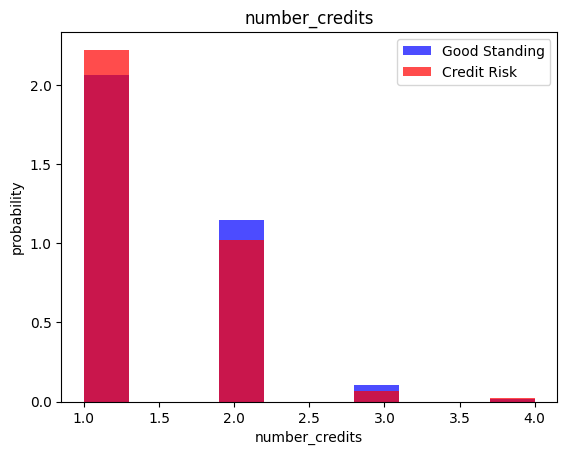

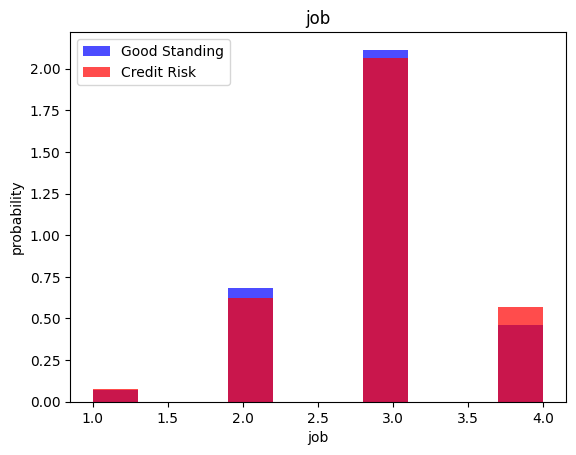

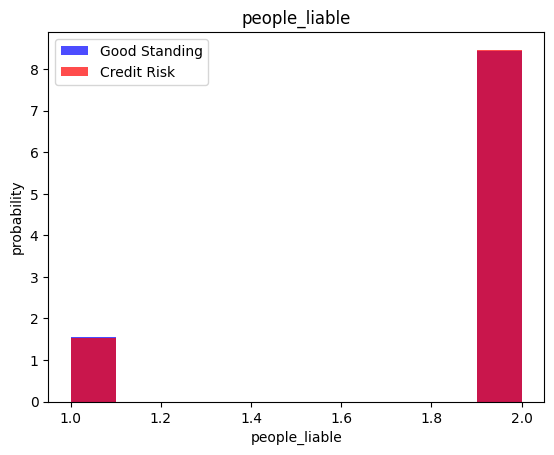

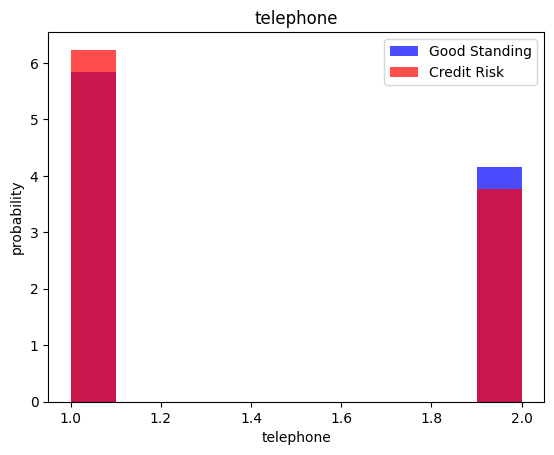

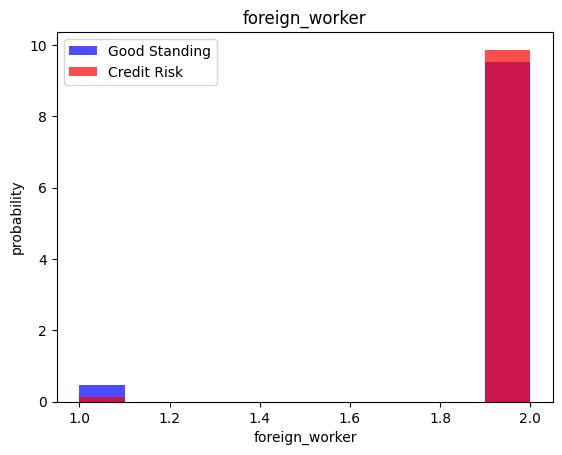

In [8]:
# Check data distribution
for label in df.columns[:-1]:
    plt.hist(df[df["credit_risk"]==1][label], color='blue', label = 'Good Standing', alpha = 0.7, density = True)
    plt.hist(df[df["credit_risk"]==0][label], color='red', label = 'Credit Risk', alpha = 0.7, density = True)
    plt.title(label)
    plt.ylabel("probability")
    plt.xlabel(label)
    plt.legend()
    plt.show()

In [9]:
# Get features with high skewness
print("Skewness:")
for label in df[:-1]:
    if df[label].skew() >= 1:
        print(f"{label}: {df[label].skew()}")

Skewness:
duration: 1.0941841715555418
purpose: 1.1788870343819051
amount: 1.9495942869127831
savings: 1.016676876742253
other_debtors: 3.264248775770769
age: 1.0247120249859745
number_credits: 1.272575967002092


### Checking for imbalance
It's also good practice to check for imbalance in our dataset to avoid developing class bias during training. Here we see **Good Standing** data more than doubles **Credit Risk**, this must be addressed before training our model.

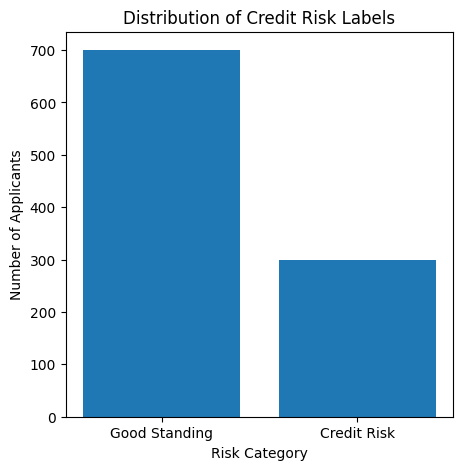

In [10]:
# Plot target distribution
counts = df['credit_risk'].value_counts()
values = [counts.get(1, 0), counts.get(0, 0)]
labels = ['Good Standing', 'Credit Risk']

plt.figure(figsize=(5, 5))
plt.bar(labels, values)
plt.title('Distribution of Credit Risk Labels', fontsize=12)
plt.xlabel('Risk Category', fontsize=10)
plt.ylabel('Number of Applicants', fontsize=10)

plt.show()

### Feature Correlation
A feature correlation heatmap is a great way to visualize our data. Looking at the correlation between the features and the target, this lines up with our initial assement of `status` being a good predictor of credit risk. A heatmap can also help us detect multicollinearity which is when multiple independent features have very high correlation. Multicollinearity can confuse our model and make coefficients unstable therefore if we spot one, it is recommended to drop one to simplify the model. Because the highest correlation in our dataset is only 0.62, all features will be retained.

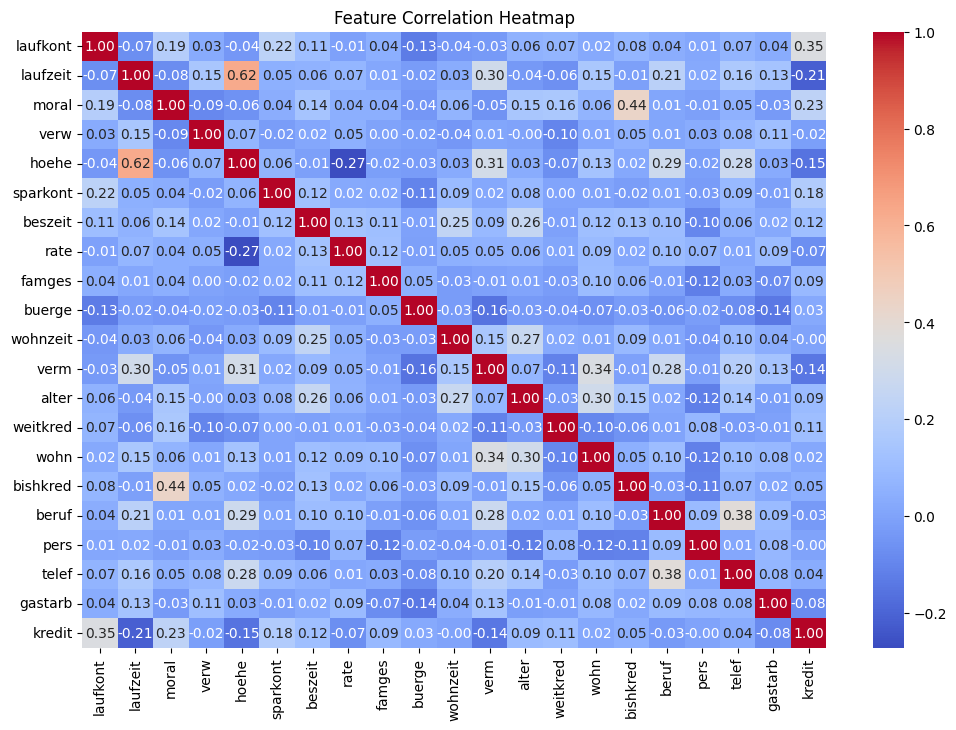

In [37]:
#Feature correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

***
## Data Preprocessing
#### Split Data into train and test
This is where we split the original dataset into training and testing subsets. The training set will be used to teach our models and testing set to evaluate them. We also separate our predictors/features (X) and the target (y)

In [12]:
# Split features and target
X = df.drop(columns = ['credit_risk'])
y = df['credit_risk']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#### Apply log transformation
As mentioned, skewed data can be detrimental to our model. This can cause poor generalization and some models assume equal variance in our data, applying log transformation essentially compresses it. The features `amount` and `duration` will be transformed. While `age` was also seen with a high degree of skewness, it is usually alright to keep it as it is since its value is naturally constrained within a narrow range and this maintains interpretability of the feature.

In [13]:
# Transform skewed columns
skewed_cols = ['amount', 'duration']
X_train[skewed_cols] = np.log1p(X_train[skewed_cols])
X_test[skewed_cols] = np.log1p(X_test[skewed_cols])

#### Scale Data
Scaling the data is important when we have numerical columns that differ significantly in magnitude because the model might assign disproportionate weights to the features. Scaling our data essentially puts every feature on an equal footing.

In [14]:
# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Resample Data
The primary reason we resample data is to balance the classes of our dataset. For credit risk cases, it is normal to have vastly more good standing than credit risk data. If we train our model on this kind of dataset, the model can just predict "Good Standing" in every case and still get a high accuracy score. Resampling the data removes this class imbalance by increasing the number of bad/risk cases to match that of the good ones.

In [15]:
# Resample data
sm = SMOTE(random_state = 42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print(f"Resampled dataset risk distribution: {pd.Series(y_train).value_counts()}")

Resampled dataset risk distribution: credit_risk
1    562
0    562
Name: count, dtype: int64


***
## Baseline Model Training
In this section, we test and evaluate different machine learning algorithms to identify a good performance baseline for credit risk prediction. The following models are trained and benchmarked:
- Logistic Regression
- K-Nearest Neighbors
- Naive Bayes
- Support Vector Machines
- Random Forest Classifier
- Extreme Gradient Boosting
- Neural Networks

The accuracies for each algorithm will be taken which is simply the ratio of correct predictions to the total number of predictions made. This is the simplest form of measure in machine learning and is intuitive to use for initial model assessment. We will also look at their confusion matrix to gain a deeper understanding of the models' behavior. This allows us to identify their patterns of success/failures by looking at the "False Alarms" (False Positives) and "Missed Cases" (False Negatives).

#### Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
# Choose model
log_model = LogisticRegression(max_iter=10000)

# Train model
log_model = log_model.fit(X_train, y_train)
log_accuracy = log_model.score(X_test, y_test)
print(f"Accuracy {log_accuracy:.4f}")

Accuracy 0.7650


In [18]:
# Classification report and confusion matrix
log_y_pred = log_model.predict(X_test)
print(classification_report(y_test, log_y_pred))
print(confusion_matrix(y_test, log_y_pred))

              precision    recall  f1-score   support

           0       0.60      0.74      0.66        62
           1       0.87      0.78      0.82       138

    accuracy                           0.77       200
   macro avg       0.73      0.76      0.74       200
weighted avg       0.79      0.77      0.77       200

[[ 46  16]
 [ 31 107]]


#### K-Nearest Neighbors

In [19]:
from sklearn.neighbors import KNeighborsClassifier

In [20]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model = knn_model.fit(X_train, y_train)
knn_accuracy = knn_model.score(X_test, y_test)
print(f"Accuracy: {knn_accuracy:.4f}")

Accuracy: 0.6800


In [21]:
knn_y_pred = knn_model.predict(X_test)
print(classification_report(y_test, knn_y_pred))
print(confusion_matrix(y_test, knn_y_pred))

              precision    recall  f1-score   support

           0       0.49      0.71      0.58        62
           1       0.84      0.67      0.74       138

    accuracy                           0.68       200
   macro avg       0.66      0.69      0.66       200
weighted avg       0.73      0.68      0.69       200

[[44 18]
 [46 92]]


#### Naive Bayes

In [22]:
from sklearn.naive_bayes import GaussianNB

In [23]:
nb_model = GaussianNB()

nb_model = nb_model.fit(X_train, y_train)
nb_accuracy = nb_model.score(X_test, y_test)
print(f"Accuracy: {nb_accuracy:.4f}")

Accuracy: 0.6400


In [24]:
nb_y_pred = nb_model.predict(X_test)
print(classification_report(y_test, nb_y_pred))
print(confusion_matrix(y_test, nb_y_pred))

              precision    recall  f1-score   support

           0       0.45      0.74      0.56        62
           1       0.84      0.59      0.69       138

    accuracy                           0.64       200
   macro avg       0.64      0.67      0.63       200
weighted avg       0.72      0.64      0.65       200

[[46 16]
 [56 82]]


#### Support Vector Machine

In [25]:
from sklearn.svm import SVC

In [26]:
svm_model = SVC()

svm_model = svm_model.fit(X_train, y_train)
svm_accuracy = svm_model.score(X_test, y_test)
print(f"Accuracy: {svm_accuracy:.4f}")

Accuracy: 0.7250


In [27]:
svm_y_pred = svm_model.predict(X_test)
print(classification_report(y_test, svm_y_pred))
print(confusion_matrix(y_test, svm_y_pred))

              precision    recall  f1-score   support

           0       0.55      0.65      0.59        62
           1       0.83      0.76      0.79       138

    accuracy                           0.72       200
   macro avg       0.69      0.70      0.69       200
weighted avg       0.74      0.72      0.73       200

[[ 40  22]
 [ 33 105]]


#### Random Forest Classifier

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
rf_model = RandomForestClassifier(random_state=42)

rf_model = rf_model.fit(X_train, y_train)
rf_accuracy = rf_model.score(X_test, y_test)
print(f"Accuracy: {rf_accuracy:.4f}")

Accuracy: 0.7750


In [30]:
rf_y_pred = rf_model.predict(X_test)
print(classification_report(y_test, rf_y_pred))
print(confusion_matrix(y_test, rf_y_pred))

              precision    recall  f1-score   support

           0       0.67      0.55      0.60        62
           1       0.81      0.88      0.84       138

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200

[[ 34  28]
 [ 17 121]]


#### Extreme Gradient Boosting

In [32]:
from xgboost import XGBClassifier

xgb_least_val_loss = float('inf')
xgb_model = None

# Test xgb model with different hyperparameters
for ne in [100, 400, 700, 1000]:
    for lr in [0.01, 0.005, 0.001]:
        for md in [3, 5, 7, 10]:
            xgb_train_model = XGBClassifier(
                n_estimators = ne,      
                learning_rate = lr,     
                max_depth = md,           
                random_state=42,
                eval_metric='logloss',
                verbosity = 0
            )

            xgb_train_model.fit(X_train, 
                          y_train, 
                          eval_set=[(X_train, y_train), (X_test, y_test)], 
                          verbose=0)
            
            loss_results = xgb_train_model.evals_result()
            val_loss = loss_results['validation_1']['logloss'][-1]
            if val_loss < xgb_least_val_loss:
                xgb_least_val_loss = val_loss
                xgb_model = xgb_train_model

xgb_y_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
print(f"Accuracy: {xgb_accuracy:.2%}")

Accuracy: 76.50%


In [33]:
print(classification_report(y_test, xgb_y_pred))
print(confusion_matrix(y_test, xgb_y_pred))

              precision    recall  f1-score   support

           0       0.63      0.58      0.61        62
           1       0.82      0.85      0.83       138

    accuracy                           0.77       200
   macro avg       0.72      0.71      0.72       200
weighted avg       0.76      0.77      0.76       200

[[ 36  26]
 [ 21 117]]


#### Neural Network

In [33]:
import tensorflow as tf

In [34]:
# Plot training history
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
  ax1.plot(history.history['loss'], label='loss')
  ax1.plot(history.history['val_loss'], label='val_loss')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Binary crossentropy')
  ax1.grid(True)

  ax2.plot(history.history['accuracy'], label='accuracy')
  ax2.plot(history.history['val_accuracy'], label='val_accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  ax2.grid(True)

  return plt.show()

In [35]:
# Neural net model function
def train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
    n_features = X_train.shape[1]
    nn_train_model = tf.keras.Sequential([
      tf.keras.layers.Input(shape=(n_features,)),
      tf.keras.layers.Dense(num_nodes, activation='relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes, activation='relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    nn_train_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr), 
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = nn_train_model.fit(
        X_train, y_train, 
        epochs=epochs, 
        batch_size=batch_size,
        shuffle=True,
        validation_split=0.2, 
        verbose=0
    )
    
    return nn_train_model, history

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6850 - loss: 3.7490 
16 nodes, dropout 0, lr 0.01, batch size 32


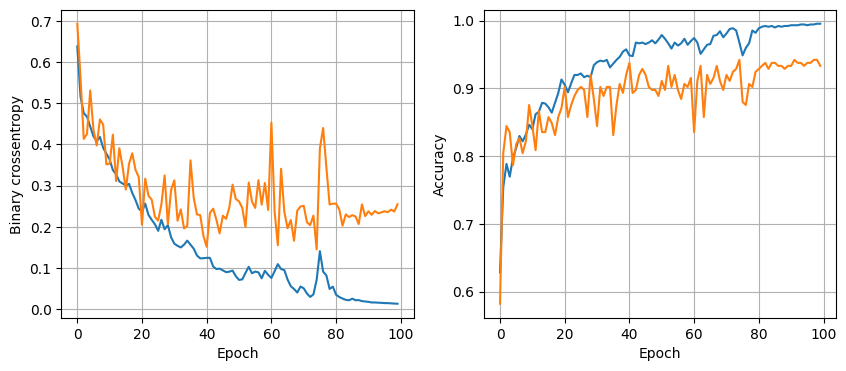

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7500 - loss: 2.2148 
16 nodes, dropout 0, lr 0.01, batch size 64


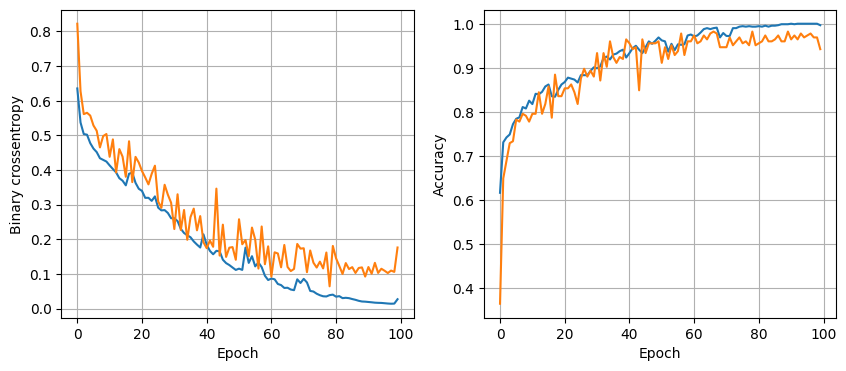

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6800 - loss: 1.1831 
16 nodes, dropout 0, lr 0.01, batch size 128


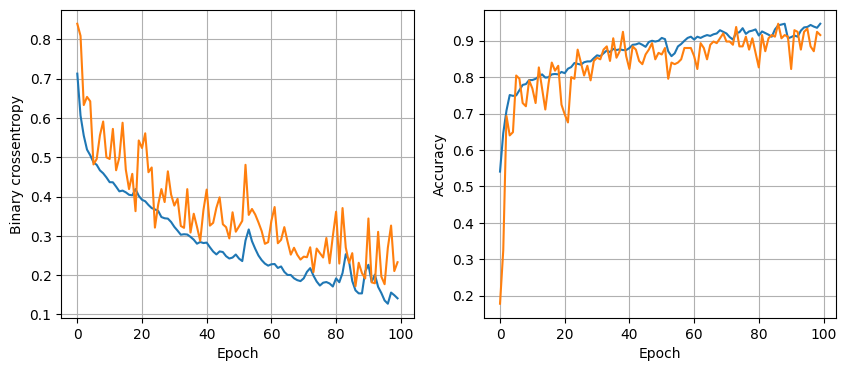

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7700 - loss: 1.6748 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7350 - loss: 1.2086 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7600 - loss: 0.6997 
16 nodes, dropout 0, lr 0.005, batch size 128


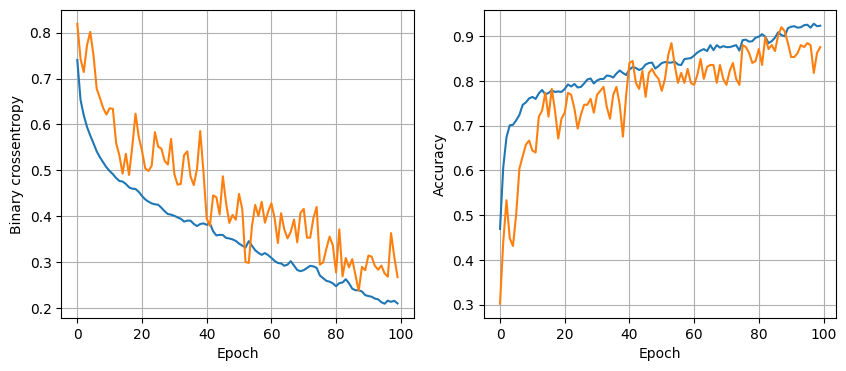

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7100 - loss: 0.6320 
16 nodes, dropout 0, lr 0.001, batch size 32


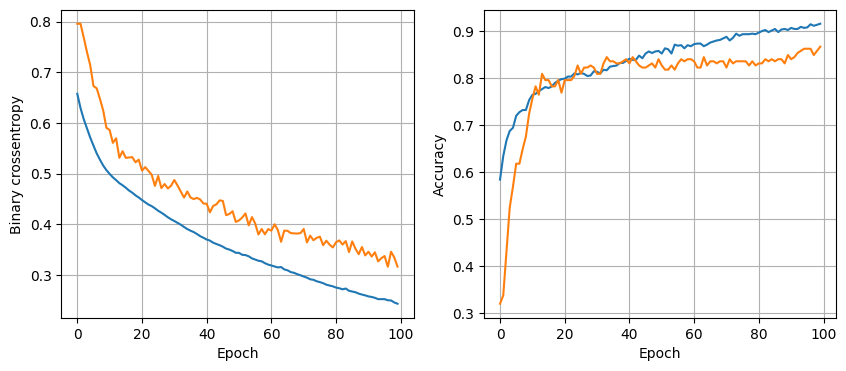

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7650 - loss: 0.5919 
16 nodes, dropout 0, lr 0.001, batch size 64


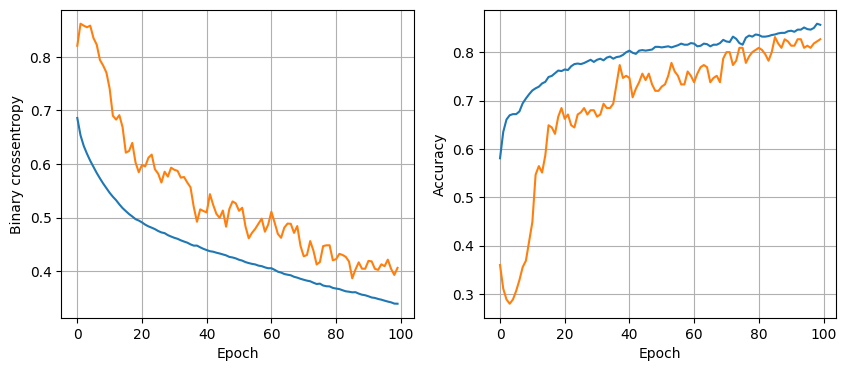

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7600 - loss: 0.5097 
16 nodes, dropout 0, lr 0.001, batch size 128


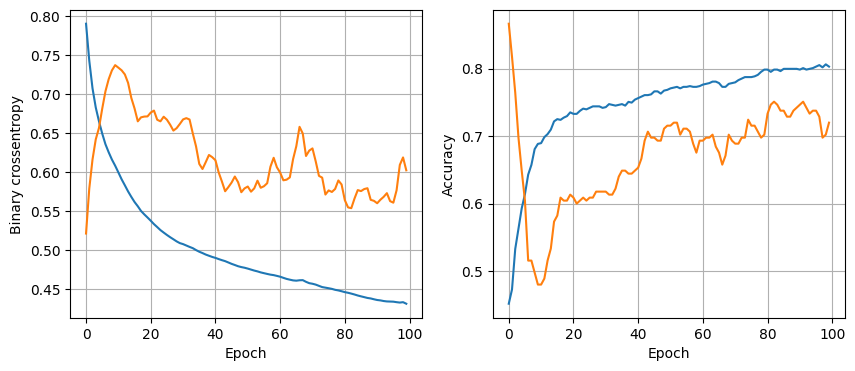

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7500 - loss: 0.6826 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7100 - loss: 0.6811 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7550 - loss: 0.6066 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7300 - loss: 0.6597 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7150 - loss: 0.6472 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7850 - loss: 0.5292 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7450 - loss: 0.5323 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7800 - loss: 0.5163 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7450 - loss: 0.5083 
16 nodes, dropout 0.2, lr 0.001, batch size 128


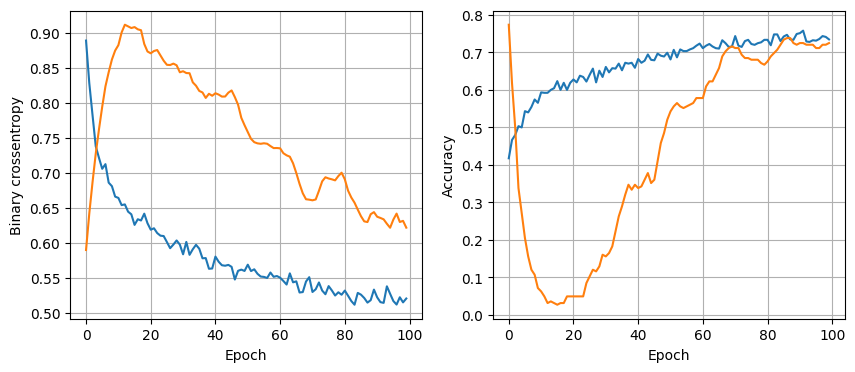

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7600 - loss: 2.3764 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7100 - loss: 2.3383 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7250 - loss: 1.6761 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7050 - loss: 2.1391 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7050 - loss: 1.7067 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7400 - loss: 1.2026 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7400 - loss: 0.8471 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7150 - loss: 0.6921 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7550 - loss: 0.5575 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7450 - loss: 0.8100 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7300 - loss: 0.9940 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7700 - loss: 0.5957 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7400 - loss: 0.9164 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7650 - loss: 

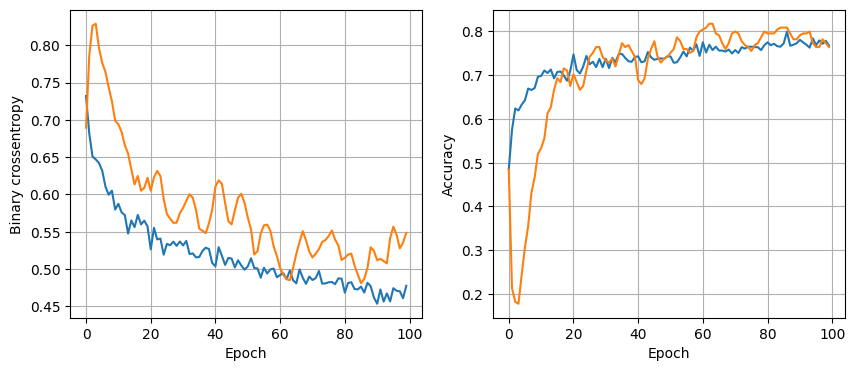

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7050 - loss: 2.7304 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7450 - loss: 2.2101 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6900 - loss: 1.7631 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7150 - loss: 2.3106 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7250 - loss: 1.8451 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7250 - loss: 1.4958 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7550 - loss: 1.4045 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6950 - loss: 0.9062 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7500 - loss: 0.5586 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7400 - loss: 1.3666 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7450 - loss: 1.0870 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7600 - loss: 0.9542 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7400 - loss: 1.2919 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7300 - loss: 

In [36]:
# Run the model through different combinations of hyperparameters
least_val_loss = float('inf')
nn_model = None
epochs = 100

for nodes in [16, 32, 64, 128]:
    for drop in [0, 0.2]:
        for rate in [0.01, 0.005, 0.001]:
            for batch in [32, 64, 128]:
                nn_train_model, history = train_model(X_train, y_train, nodes, drop, rate, batch, epochs)
                val_loss = nn_train_model.evaluate(X_test, y_test)[0]
                if val_loss < least_val_loss:
                    least_val_loss = val_loss
                    nn_model = nn_train_model
                    print(f"{nodes} nodes, dropout {drop}, lr {rate}, batch size {batch}")
                    plot_history(history)

In [37]:
nn_y_probs = nn_model.predict(X_test)
nn_y_pred = (nn_y_probs > 0.5).astype(int).flatten()

report = classification_report(y_test, nn_y_pred, output_dict=True)
nn_accuracy = report['accuracy']
print(f"Accuracy {nn_accuracy:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Accuracy 0.7800


In [38]:
print(classification_report(y_test, nn_y_pred))
print(confusion_matrix(y_test, nn_y_pred))

              precision    recall  f1-score   support

           0       0.67      0.56      0.61        62
           1       0.82      0.88      0.85       138

    accuracy                           0.78       200
   macro avg       0.75      0.72      0.73       200
weighted avg       0.77      0.78      0.77       200

[[ 35  27]
 [ 17 121]]


***
## Evaluate Base Models
Based on the accuracies, we choose the following models for further tuning:
- Logistic Regression
- Random Forest
- Extreme Gradient Boosting
- Neural Network

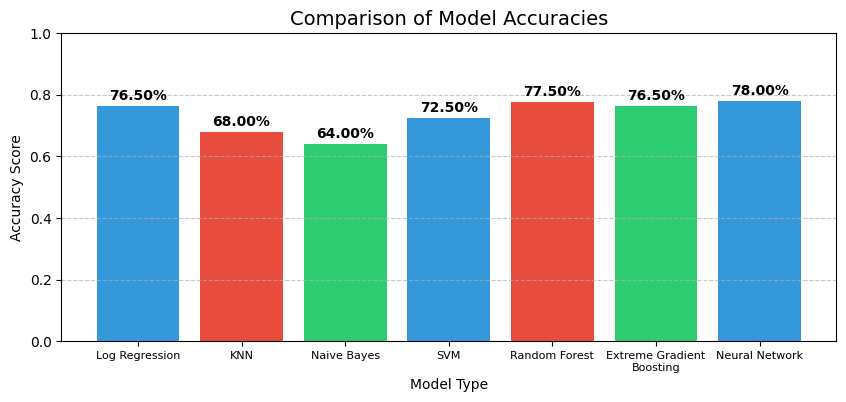

In [39]:
# Bar graph visualization of the models
models = ['Log Regression', 'KNN', 'Naive Bayes', 'SVM', 'Random Forest', 'Extreme Gradient\nBoosting', 'Neural Network']
accuracies = [log_accuracy, knn_accuracy, nb_accuracy, svm_accuracy, rf_accuracy, xgb_accuracy, nn_accuracy]

plt.figure(figsize=(10, 4))
bars = plt.bar(models, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'])
plt.xticks(fontsize=8, rotation = 0)
plt.xlabel('Model Type', fontsize=10)
plt.ylabel('Accuracy Score', fontsize=10)
plt.title('Comparison of Model Accuracies', fontsize=14)
plt.ylim(0, 1.0)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.2%}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

***
## Tuning Hyperparameters
Each model has hyperparameters that we can tune which may increase the accuracy we get than if we were to use the default values. Having already optimized our Extreme Gradient Boosting and Neural Network hyperparameters, let's apply the similar tuning strategy for Logistic Regression and Random Forest Classifier. For the two models, we will use GridSearchCV to check different combinations of the hyperparameters.

In [40]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import GridSearchCV

#### Logistic Regression

In [41]:
# Define the parameter grid
log_param = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['saga'],           
    'penalty': ['elasticnet'],     
    'l1_ratio': [0, 0.5, 1]       
}

log_model = LogisticRegression()
log_model = GridSearchCV(log_model, log_param, cv=5, scoring='accuracy')

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    log_model.fit(X_train, y_train)

print(f"Best LogReg Parameters: {log_model.best_params_}")

Best LogReg Parameters: {'C': 0.1, 'l1_ratio': 0, 'penalty': 'elasticnet', 'solver': 'saga'}


In [42]:
log_accuracy = log_model.score(X_test, y_test)
print(f"Accuracy: {log_accuracy:.4f}")

Accuracy: 0.7650


In [43]:
log_y_pred = log_model.predict(X_test)
print(classification_report(y_test, log_y_pred))
print(confusion_matrix(y_test, log_y_pred))

              precision    recall  f1-score   support

           0       0.60      0.74      0.66        62
           1       0.87      0.78      0.82       138

    accuracy                           0.77       200
   macro avg       0.73      0.76      0.74       200
weighted avg       0.79      0.77      0.77       200

[[ 46  16]
 [ 31 107]]


#### Random Forest Classifier

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_model = GridSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
rf_model.fit(X_train, y_train)

print(f"Best RF Parameters: {rf_model.best_params_}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best RF Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}


In [32]:
rf_accuracy = rf_model.score(X_test, y_test)
print(f"Accuracy: {rf_accuracy:.4f}")

Accuracy: 0.7850


In [33]:
rf_y_pred = rf_model.predict(X_test)
print(classification_report(y_test, rf_y_pred))
print(confusion_matrix(y_test, rf_y_pred))

              precision    recall  f1-score   support

           0       0.68      0.58      0.63        62
           1       0.82      0.88      0.85       138

    accuracy                           0.79       200
   macro avg       0.75      0.73      0.74       200
weighted avg       0.78      0.79      0.78       200

[[ 36  26]
 [ 17 121]]


***
## Evaluate Tuned Models

Let's compare the accuracies of the tuned models:

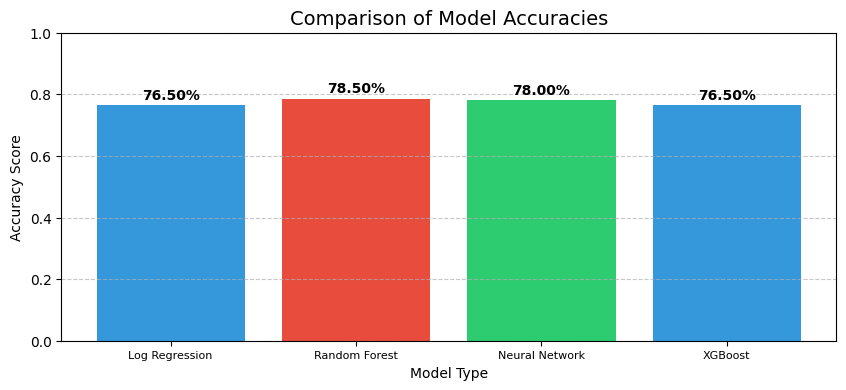

In [47]:
models = ['Log Regression', 'Random Forest', 'Neural Network', 'XGBoost']
accuracies = [log_accuracy, rf_accuracy, nn_accuracy, xgb_accuracy]


plt.figure(figsize=(10, 4))
bars = plt.bar(models, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'])
plt.xticks(fontsize=8, rotation = 0)
plt.xlabel('Model Type', fontsize=10)
plt.ylabel('Accuracy Score', fontsize=10)
plt.title('Comparison of Model Accuracies', fontsize=14)
plt.ylim(0, 1.0)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.2%}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From the figure above, we see that Random Forest Classifier got the highest accuracy post-tuning at 78.5%, followed by Random Forest at 78%, and Logistic Regression and Extreme Gradient Boosting is tied at 76.5%. While the four models have a narrow margin, accuracy alone does not provide the full picture. 

For credit risk assessment, it's typically more important that our model does not approve high risk loans. In order to see this, let's compare the models' confusion matrices and classification report.

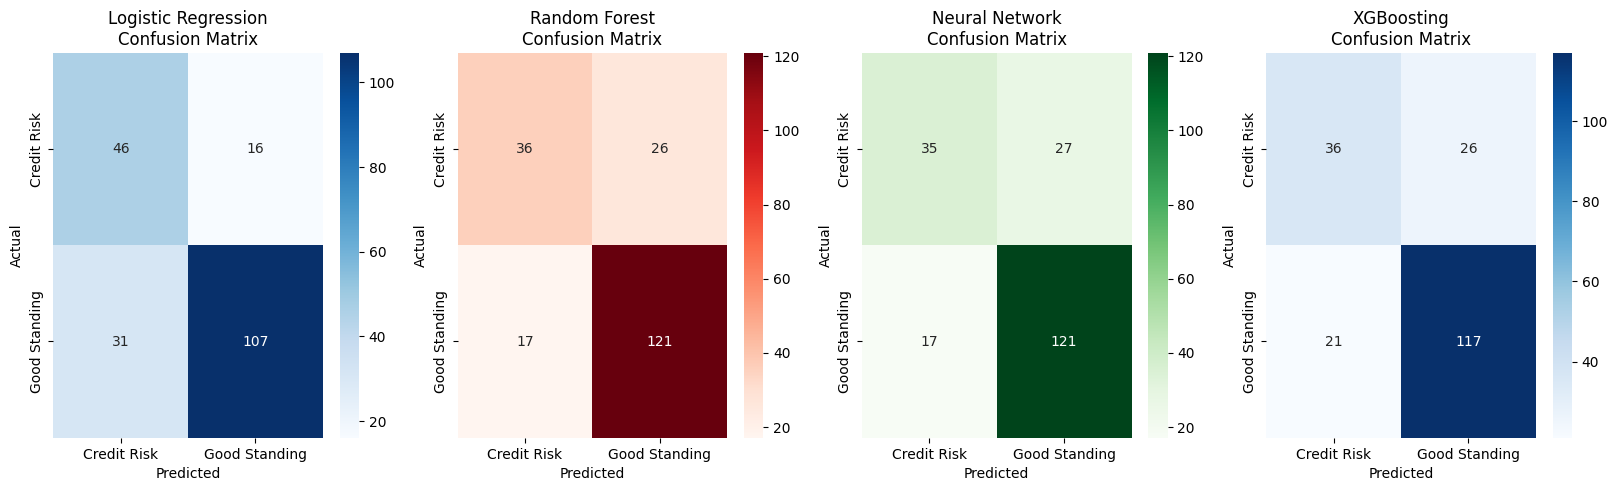

In [48]:
# Plot confusion matrix heatmap side by side
cm_log = confusion_matrix(y_test, log_y_pred)
cm_rf = confusion_matrix(y_test, rf_y_pred)
cm_nn = confusion_matrix(y_test, nn_y_pred)
cm_xgb = confusion_matrix(y_test, xgb_y_pred)

Fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['Credit Risk', 'Good Standing'], 
            yticklabels=['Credit Risk', 'Good Standing'])
ax1.set_title('Logistic Regression\nConfusion Matrix', fontsize=12)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', ax=ax2, 
            xticklabels=['Credit Risk', 'Good Standing'], 
            yticklabels=['Credit Risk', 'Good Standing'])
ax2.set_title('Random Forest\nConfusion Matrix', fontsize=12)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens', ax=ax3, 
            xticklabels=['Credit Risk', 'Good Standing'], 
            yticklabels=['Credit Risk', 'Good Standing'])
ax3.set_title('Neural Network\nConfusion Matrix', fontsize=12)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=ax4, 
            xticklabels=['Credit Risk', 'Good Standing'], 
            yticklabels=['Credit Risk', 'Good Standing'])
ax4.set_title('XGBoosting\nConfusion Matrix', fontsize=12)
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

plt.show()

In [49]:
ypreds = {"Logistic Regression": log_y_pred, "Random Forest": rf_y_pred, "Neural Network": nn_y_pred, "XGBoosting": xgb_y_pred}
comparison_data = {}

for name, ypred in ypreds.items():
    report = classification_report(y_test, ypred, output_dict=True)
    
    comparison_data[name] = {
        "Accuracy": report["accuracy"],
        "Precision (Class 1)": report["1"]["precision"],
        "Recall (Class 1)": report["1"]["recall"],
        "Macro F1": report["macro avg"]["f1-score"]
    }

df_compare = pd.DataFrame(comparison_data).T
print(df_compare)

                     Accuracy  Precision (Class 1)  Recall (Class 1)  Macro F1
Logistic Regression     0.765             0.869919          0.775362  0.740897
Random Forest           0.785             0.823129          0.876812  0.737605
Neural Network          0.780             0.817568          0.876812  0.730094
XGBoosting              0.765             0.818182          0.847826  0.718891


The confusion matrix gives us a deeper look into the specific trade-offs in each model. At first glance, Random Forest Classifier seems to provide the best performance because of its high accuracy. However, Logistic Regression model has successfully identified the most number of risky loans at 46 making it the "safest" model. Looking at Precision (Class 1), it has a score of around 0.87 which means whenever it makes a prediction that someone is a good customer, it is correct 87% of the time. The downside of this model is it also has the highest amount of false alarms at 31, meaning it might reject good applicants more frequently than the other models. 

The "best" model depends on the institution's priority. If the priority is to avoid credit risks, Logistic Regression wins due to superior Precision. However if they prefer having more customers and avoid turning away good applicants, then Random Forest Classifier is ideal.

***
## Feature Importance
In order to explain how our models make their judgement, we can look at the Feature Importance. Feature Importance shows us how strong of a predictor each feature is and how it influences the model's prediction. In the figure below, `status`, `savings` and `credit_history` have the strongest positive correlation while `duration` and `installment_rate` have negative weights. For example, a higher `status` or checking account balance increases the likelihood of the model predicting "Good Standing". On the other hand, a higher `duration` makes the model lean towards "Credit Risk". This is important to know because it is often not enough to simply provide a "Yes" or "No" for a loan, the institution should be able to explain why they made the decision. By knowing that our strongest predictors are `status` and `savings`, we can say that the model prioritizes financial stability.

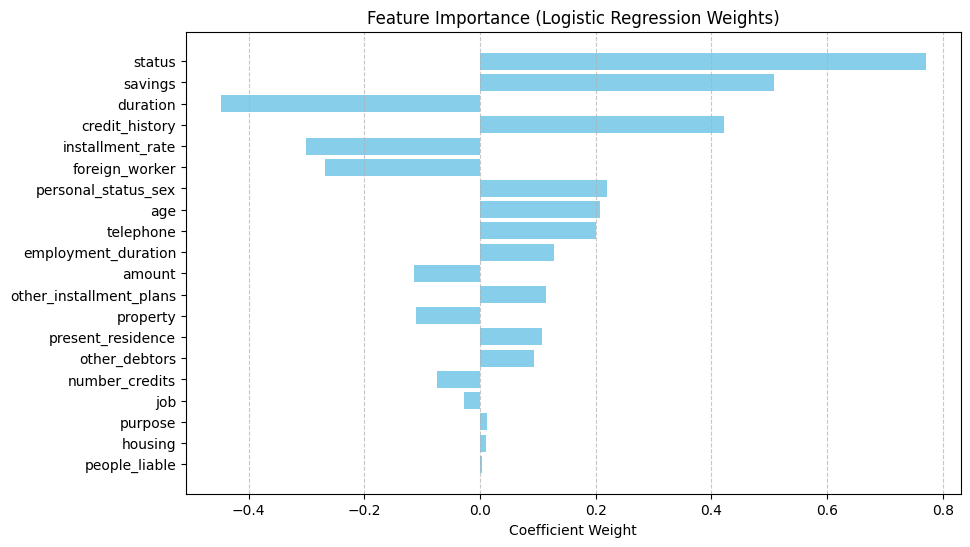

In [50]:
# Feature Importance Coefficient
coefficients = log_model.best_estimator_.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Weight': coefficients
})

feature_importance['Abs_Weight'] = feature_importance['Weight'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Weight', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Weight'], color='skyblue')
plt.xlabel('Coefficient Weight')
plt.title('Feature Importance (Logistic Regression Weights)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

***
## Future Improvements

To further enhance the performance of our models, there are other several methods that could be explored. 

A lot of the features in our dataset are categorical or has ordinal encoding. This can sometimes imply that there's a numerical distance between categories which in actuality does not exist. In order to improve this, One-Hot Encoding can be implemented to these features. This may reveal non-linear relationships in these features that our model is currently missing.

Another thing that we can do is tweaking our model's threshold to be more stricter when making predictions. Since Random Forest Classifier has the highest accuracy, we can check if the trade-off of lowering it's overall accuracy to increase Precision can make it outperform Logistic Regression in terms of identifying risky applicants.

Once we're done improving our models, we can try making a Majority Voting Classifier or Weighted Average ensemble out of them. This is basically like making a "board of directors" to make a decision. By combining Logistic Regression's high precision and Random Forest's high recall, we can create a more robust final predictor.

Ultimately, these are just the tip of the iceberg. There are countless ways to engineer our dataset, tune hyperparameters, and design our models to make it more fitting to our specific goals.